In [1]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

# Saving model
import joblib

sns.set_style("whitegrid")

RANDOM_STATE = 42

In [2]:

df = pd.read_csv("loan_data.csv")

df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   object 
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 1.0+ MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
credit.policy,9578.0,0.804970,0.396245,0.000000,1.000000,1.000000,1.000000,1.000000e+00
int.rate,9578.0,0.122640,0.026847,0.060000,0.103900,0.122100,0.140700,2.164000e-01
installment,9578.0,319.089413,207.071301,15.670000,163.770000,268.950000,432.762500,9.401400e+02
log.annual.inc,9578.0,10.932117,0.614813,7.547502,10.558414,10.928884,11.291293,1.452835e+01
dti,9578.0,12.606679,6.883970,0.000000,7.212500,12.665000,17.950000,2.996000e+01
fico,9578.0,710.846314,37.970537,612.000000,682.000000,707.000000,737.000000,8.270000e+02
days.with.cr.line,9578.0,4560.767197,2496.930377,178.958333,2820.000000,4139.958333,5730.000000,1.763996e+04
revol.bal,9578.0,16913.963876,33756.189557,0.000000,3187.000000,8596.000000,18249.500000,1.207359e+06
revol.util,9578.0,46.799236,29.014417,0.000000,22.600000,46.300000,70.900000,1.190000e+02
inq.last.6mths,9578.0,1.577469,2.200245,0.000000,0.000000,1.000000,2.000000,3.300000e+01


In [8]:
df.isnull().sum()

credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
target_counts = df["not.fully.paid"].value_counts()

print(target_counts)

print("\nTarget percentages:")
print(
    df["not.fully.paid"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

not.fully.paid
0    8045
1    1533
Name: count, dtype: int64

Target percentages:
not.fully.paid
0    83.99
1    16.01
Name: proportion, dtype: float64


In [16]:
df['not.fully.paid'].value_counts().values/df.shape[0]*100

array([83.99457089, 16.00542911])

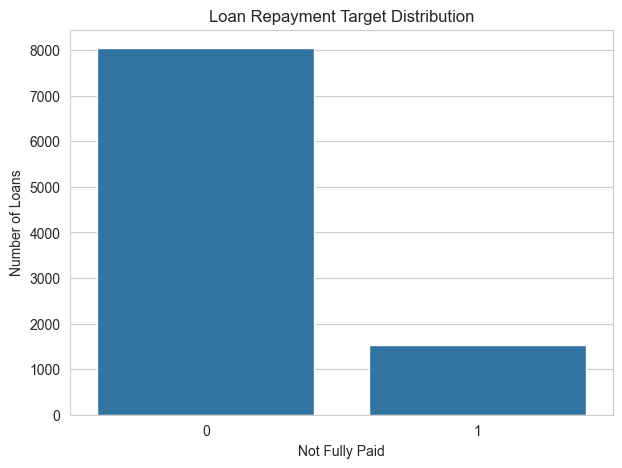

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="not.fully.paid"
)

plt.title("Loan Repayment Target Distribution")
plt.xlabel("Not Fully Paid")
plt.ylabel("Number of Loans")

plt.show()

In [18]:
print(df["purpose"].value_counts())

purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64


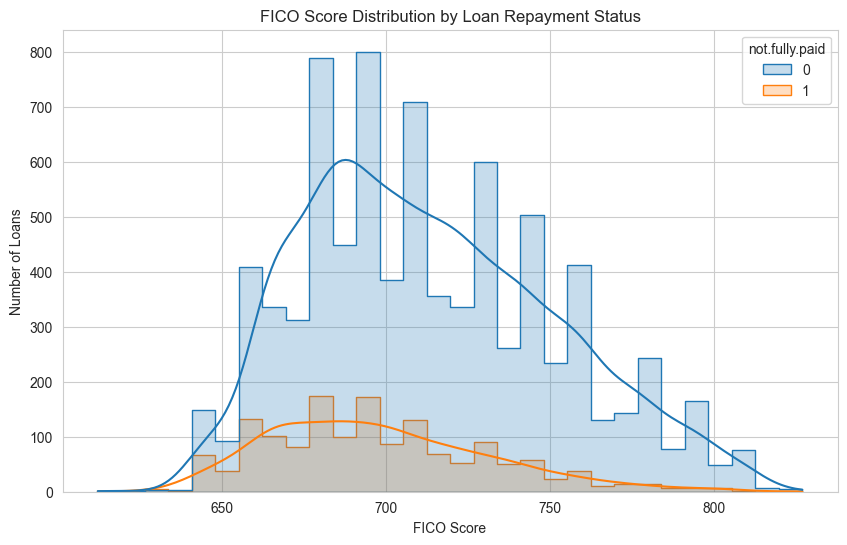

In [19]:
# ============================================
# 10. FICO DISTRIBUTION BY REPAYMENT STATUS
# ============================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="fico",
    hue="not.fully.paid",
    bins=30,
    kde=True,
    element="step"
)

plt.title("FICO Score Distribution by Loan Repayment Status")
plt.xlabel("FICO Score")
plt.ylabel("Number of Loans")

plt.show()

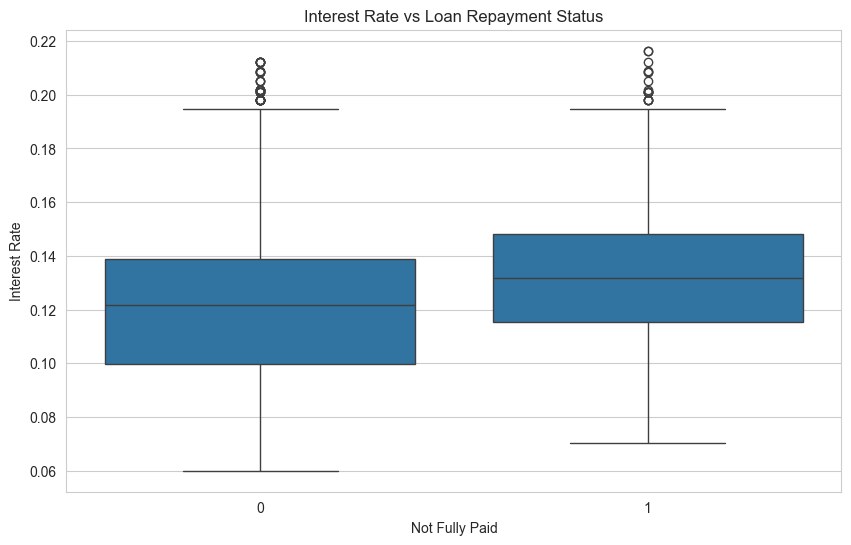

In [20]:
# ============================================
# 11. INTEREST RATE VS REPAYMENT
# ============================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="not.fully.paid",
    y="int.rate"
)

plt.title("Interest Rate vs Loan Repayment Status")
plt.xlabel("Not Fully Paid")
plt.ylabel("Interest Rate")

plt.show()

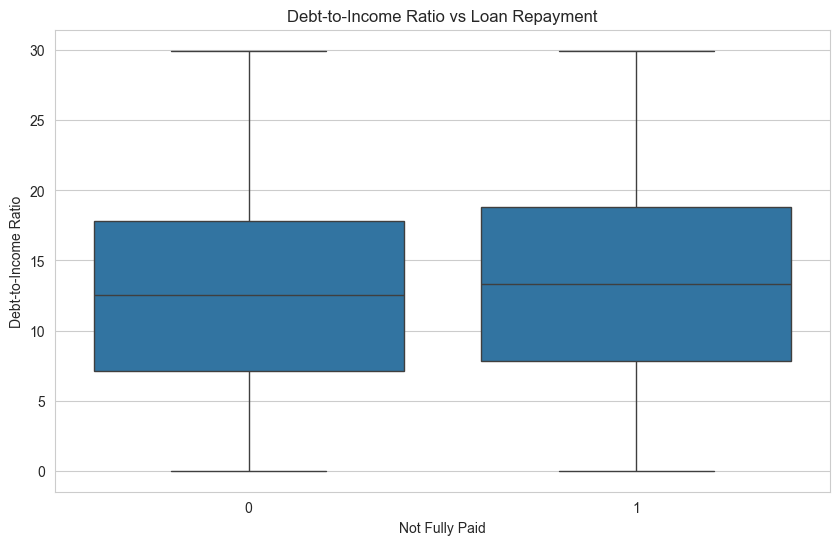

In [21]:
# ============================================
# 12. DTI VS REPAYMENT
# ============================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="not.fully.paid",
    y="dti"
)

plt.title("Debt-to-Income Ratio vs Loan Repayment")
plt.xlabel("Not Fully Paid")
plt.ylabel("Debt-to-Income Ratio")

plt.show()

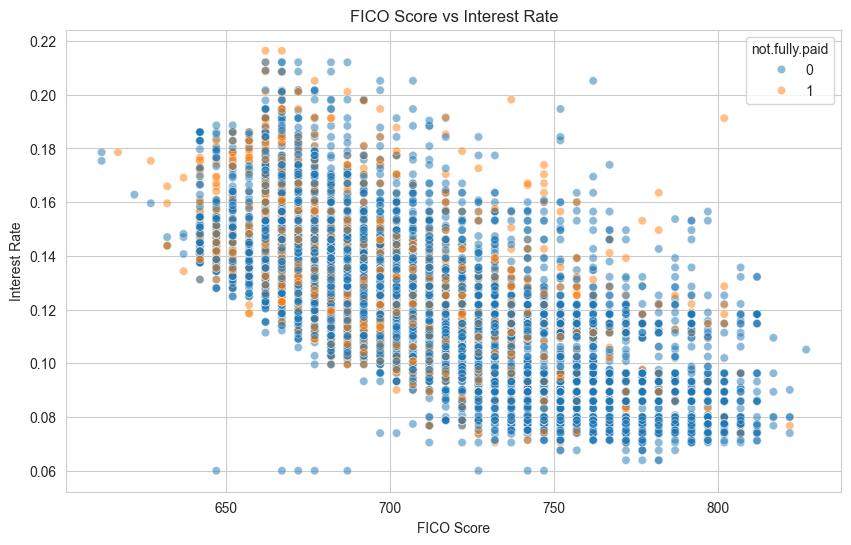

In [22]:
# ============================================
# 13. FICO VS INTEREST RATE
# ============================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="fico",
    y="int.rate",
    hue="not.fully.paid",
    alpha=0.5
)

plt.title("FICO Score vs Interest Rate")
plt.xlabel("FICO Score")
plt.ylabel("Interest Rate")

plt.show()

In [23]:
# ============================================
# 14. NON-REPAYMENT RATE BY LOAN PURPOSE
# ============================================

purpose_risk = (
    df.groupby("purpose")["not.fully.paid"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

purpose_risk["non_repayment_rate_%"] = (
    purpose_risk["mean"] * 100
)

purpose_risk

,count,mean,non_repayment_rate_%
purpose,,,
small_business,619,0.277868,27.786753
educational,343,0.201166,20.116618
home_improvement,629,0.170111,17.011129
all_other,2331,0.166023,16.602317
debt_consolidation,3957,0.152388,15.238817
credit_card,1262,0.115689,11.568938
major_purchase,437,0.112128,11.212815


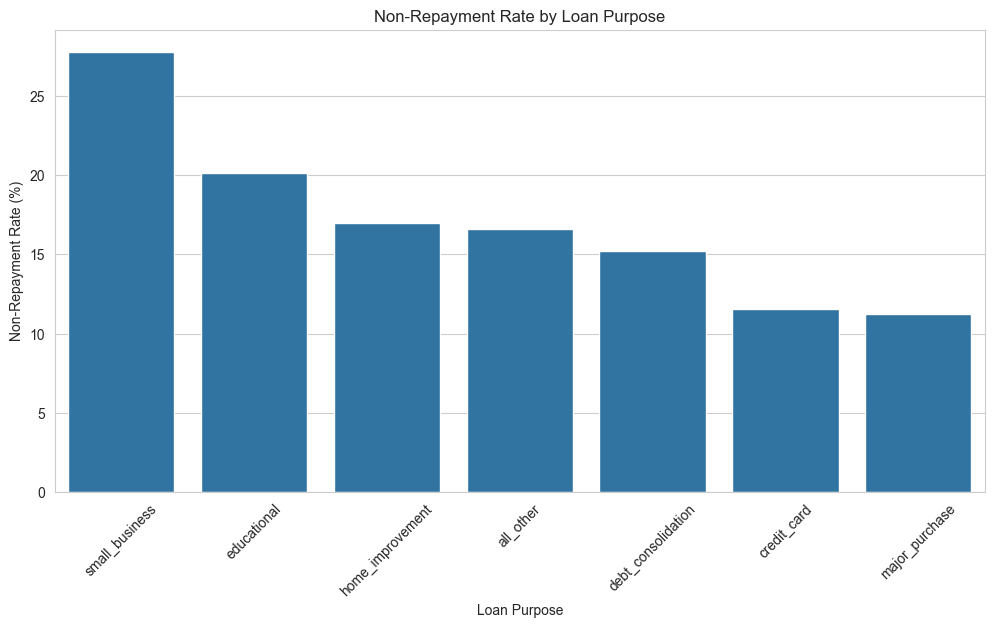

In [24]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=purpose_risk.reset_index(),
    x="purpose",
    y="non_repayment_rate_%"
)

plt.xticks(rotation=45)
plt.title("Non-Repayment Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Non-Repayment Rate (%)")

plt.show()

In [25]:
# ============================================
# 15. FEATURE ENGINEERING
# ============================================

df["credit_history_years"] = (
    df["days.with.cr.line"] / 365
)

df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,credit_history_years
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,15.451941
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,7.561644
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,12.904110
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,7.397146
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,11.139726


In [26]:
# ============================================
# 16. DEFINE FEATURES AND TARGET
# ============================================

X = df.drop("not.fully.paid", axis=1)

y = df["not.fully.paid"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9578, 14)
y shape: (9578,)


In [28]:
# ============================================
# 17. TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set: (7662, 14)
Testing set : (1916, 14)

Training target distribution:
not.fully.paid
0    0.83999
1    0.16001
Name: proportion, dtype: float64

Testing target distribution:
not.fully.paid
0    0.83977
1    0.16023
Name: proportion, dtype: float64


In [29]:
# ============================================
# 18. IDENTIFY COLUMN TYPES
# ============================================

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

Categorical features:
['purpose']

Numeric features:
['credit.policy', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'credit_history_years']


In [30]:
# ============================================
# 19. PREPROCESSING PIPELINE
# ============================================

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [31]:
# ============================================
# 20. BASELINE MODEL - LOGISTIC REGRESSION
# ============================================

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_pipeline.fit(X_train, y_train)

y_pred = logistic_pipeline.predict(X_test)
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

In [32]:
# ============================================
# 21. MODEL EVALUATION FUNCTION
# ============================================

def evaluate_model(model, X_test, y_test, model_name):

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    if y_prob is not None:
        roc_auc = roc_auc_score(
            y_test,
            y_prob
        )

        pr_auc = average_precision_score(
            y_test,
            y_prob
        )
    else:
        roc_auc = np.nan
        pr_auc = np.nan

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }

In [33]:
# ============================================
# 22. EVALUATE LOGISTIC REGRESSION
# ============================================

results = []

logistic_result = evaluate_model(
    logistic_pipeline,
    X_test,
    y_test,
    "Logistic Regression"
)

results.append(logistic_result)

Logistic Regression
Accuracy : 0.6409
Precision: 0.2394
Recall   : 0.5700
F1 Score : 0.3372
ROC-AUC  : 0.6845
PR-AUC   : 0.3029

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.65      0.75      1609
           1       0.24      0.57      0.34       307

    accuracy                           0.64      1916
   macro avg       0.56      0.61      0.55      1916
weighted avg       0.78      0.64      0.69      1916

Confusion Matrix:
[[1053  556]
 [ 132  175]]


In [34]:
# ============================================
# 23. DECISION TREE
# ============================================

dt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=5,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)

dt_pipeline.fit(X_train, y_train)

dt_result = evaluate_model(
    dt_pipeline,
    X_test,
    y_test,
    "Decision Tree"
)

results.append(dt_result)

Decision Tree
Accuracy : 0.6148
Precision: 0.2255
Recall   : 0.5765
F1 Score : 0.3242
ROC-AUC  : 0.6323
PR-AUC   : 0.2282

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.62      0.73      1609
           1       0.23      0.58      0.32       307

    accuracy                           0.61      1916
   macro avg       0.56      0.60      0.53      1916
weighted avg       0.78      0.61      0.67      1916

Confusion Matrix:
[[1001  608]
 [ 130  177]]


In [35]:
# ============================================
# 24. RANDOM FOREST
# ============================================

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=400,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_result = evaluate_model(
    rf_pipeline,
    X_test,
    y_test,
    "Random Forest"
)

results.append(rf_result)

Random Forest
Accuracy : 0.8382
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.6802
PR-AUC   : 0.2696

Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1609
           1       0.00      0.00      0.00       307

    accuracy                           0.84      1916
   macro avg       0.42      0.50      0.46      1916
weighted avg       0.71      0.84      0.77      1916

Confusion Matrix:
[[1606    3]
 [ 307    0]]


In [36]:
# ============================================
# 25. GRADIENT BOOSTING
# ============================================

gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingClassifier(
                learning_rate=0.05,
                n_estimators=200,
                max_depth=3,
                random_state=RANDOM_STATE
            )
        )
    ]
)

gb_pipeline.fit(X_train, y_train)

gb_result = evaluate_model(
    gb_pipeline,
    X_test,
    y_test,
    "Gradient Boosting"
)

results.append(gb_result)

Gradient Boosting
Accuracy : 0.8382
Precision: 0.4118
Recall   : 0.0228
F1 Score : 0.0432
ROC-AUC  : 0.6607
PR-AUC   : 0.2714

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      1609
           1       0.41      0.02      0.04       307

    accuracy                           0.84      1916
   macro avg       0.63      0.51      0.48      1916
weighted avg       0.77      0.84      0.77      1916

Confusion Matrix:
[[1599   10]
 [ 300    7]]


In [37]:
# ============================================
# 26. MODEL COMPARISON
# ============================================

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="PR-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.640919,0.239398,0.570033,0.337187,0.684458,0.302932
3,Gradient Boosting,0.838205,0.411765,0.022801,0.043210,0.660702,0.271392
2,Random Forest,0.838205,0.000000,0.000000,0.000000,0.680226,0.269597
1,Decision Tree,0.614823,0.225478,0.576547,0.324176,0.632315,0.228159


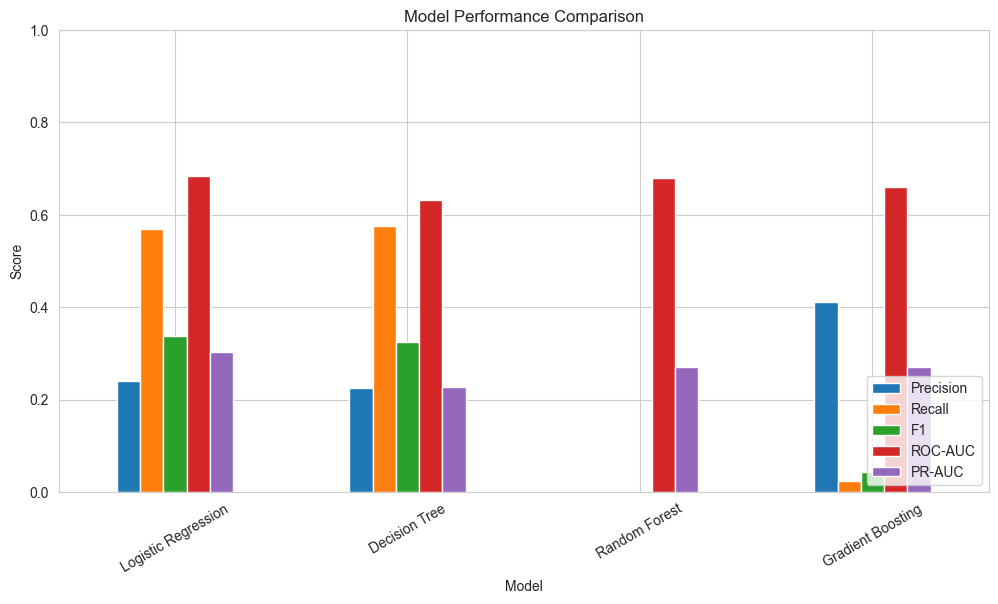

In [38]:
# ============================================
# 27. MODEL COMPARISON VISUALIZATION
# ============================================

plot_df = results_df.set_index("Model")[
    ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
]

plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(loc="lower right")

plt.show()

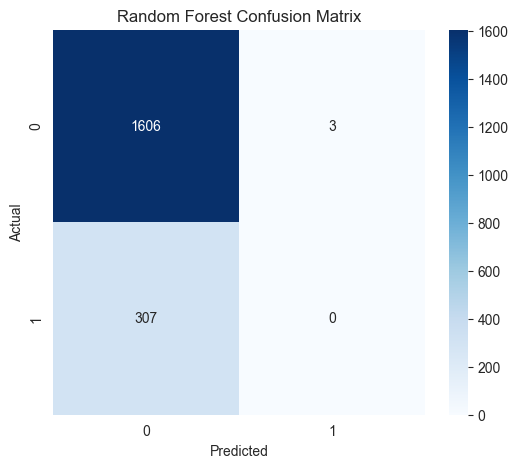

In [39]:
# ============================================
# 28. RANDOM FOREST CONFUSION MATRIX
# ============================================

y_pred_rf = rf_pipeline.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

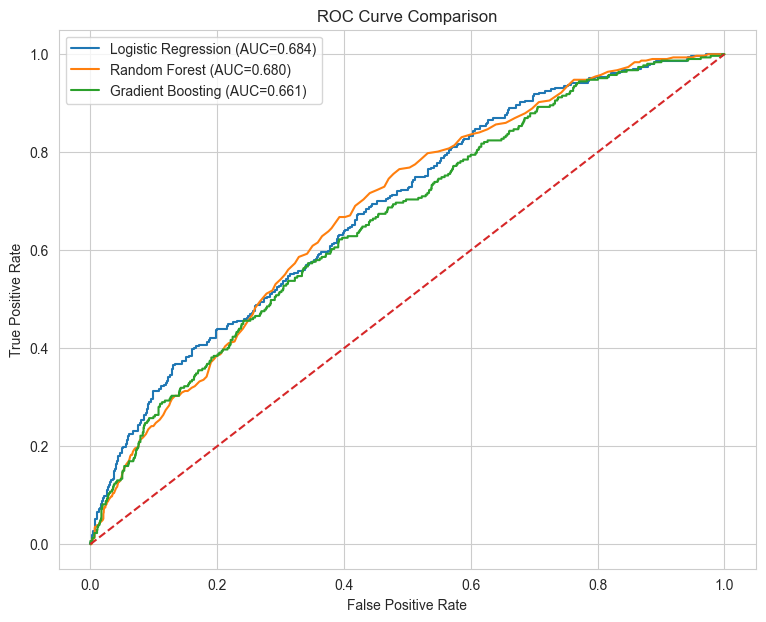

In [40]:
# ============================================
# 29. ROC CURVE
# ============================================

models_for_roc = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline
}

plt.figure(figsize=(9, 7))

for name, model in models_for_roc.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

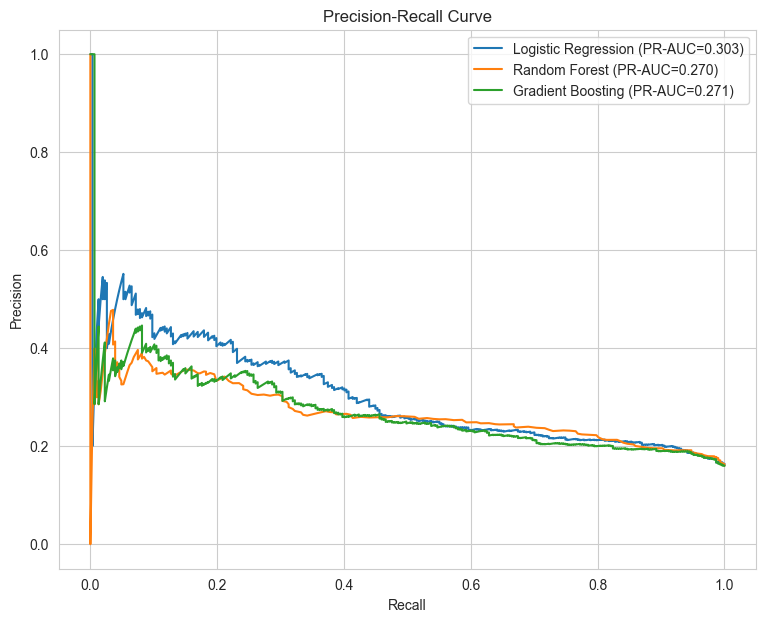

In [41]:
# ============================================
# 30. PRECISION-RECALL CURVE
# ============================================

plt.figure(figsize=(9, 7))

for name, model in models_for_roc.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (PR-AUC={pr_auc:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [42]:
# ============================================
# 31. RANDOM FOREST HYPERPARAMETER TUNING
# ============================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

rf_param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__class_weight": ["balanced", "balanced_subsample"]
}

In [43]:
# ============================================
# 32. GRID SEARCH
# ============================================

rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__class_weight': ['balanced', 'balanced_subsample'], 'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [44]:
# ============================================
# 33. BEST PARAMETERS
# ============================================

print("Best parameters:")

print(rf_grid.best_params_)

print("\nBest cross-validation PR-AUC:")

print(rf_grid.best_score_)

Best parameters:
{'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 400}

Best cross-validation PR-AUC:
0.2767097803913278


In [45]:
# ============================================
# 34. TUNED RANDOM FOREST
# ============================================

best_rf = rf_grid.best_estimator_

tuned_rf_result = evaluate_model(
    best_rf,
    X_test,
    y_test,
    "Tuned Random Forest"
)

Tuned Random Forest
Accuracy : 0.8392
Precision: 0.4783
Recall   : 0.0358
F1 Score : 0.0667
ROC-AUC  : 0.6796
PR-AUC   : 0.2825

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      1609
           1       0.48      0.04      0.07       307

    accuracy                           0.84      1916
   macro avg       0.66      0.51      0.49      1916
weighted avg       0.79      0.84      0.78      1916

Confusion Matrix:
[[1597   12]
 [ 296   11]]


In [46]:
# ============================================
# 35. THRESHOLD ANALYSIS
# ============================================

y_prob = best_rf.predict_proba(X_test)[:, 1]

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_results = []

for threshold in thresholds:

    y_threshold_pred = (
        y_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_threshold_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_threshold_pred,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.181424,0.954397,0.304891
1,0.15,0.205335,0.827362,0.329016
2,0.20,0.235426,0.684039,0.350292
3,0.25,0.265203,0.511401,0.349277
4,0.30,0.295082,0.351792,0.320951
5,0.35,0.337900,0.241042,0.281369
6,0.40,0.351351,0.127036,0.186603
7,0.45,0.446809,0.068404,0.118644
8,0.50,0.478261,0.035831,0.066667
9,0.55,0.500000,0.009772,0.019169


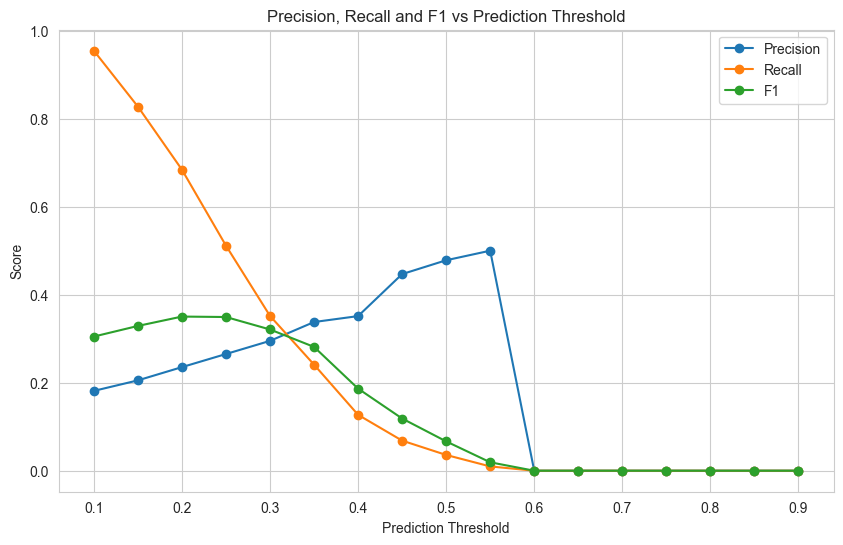

In [47]:
# ============================================
# 36. THRESHOLD PERFORMANCE
# ============================================

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"

)

plt.xlabel("Prediction Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Prediction Threshold")
plt.legend()

plt.show()

In [48]:
# ============================================
# 37. SELECT THRESHOLD BASED ON F1
# ============================================

best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print(
    "Selected threshold:",
    best_threshold
)

print(
    "\nExpected metrics at selected threshold:"
)

print(best_threshold_row)

Selected threshold: 0.20000000000000004

Expected metrics at selected threshold:
Threshold    0.200000
Precision    0.235426
Recall       0.684039
F1           0.350292
Name: 2, dtype: float64


In [49]:
# ============================================
# 38. FINAL THRESHOLD PREDICTIONS
# ============================================

final_probabilities = best_rf.predict_proba(
    X_test
)[:, 1]

final_predictions = (
    final_probabilities >= best_threshold
).astype(int)

print(
    classification_report(
        y_test,
        final_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.91      0.58      0.70      1609
           1       0.24      0.68      0.35       307

    accuracy                           0.59      1916
   macro avg       0.57      0.63      0.53      1916
weighted avg       0.80      0.59      0.65      1916



In [50]:
# ============================================
# 39. GET FEATURE NAMES
# ============================================

preprocessor_fitted = best_rf.named_steps[
    "preprocessor"
]

model_fitted = best_rf.named_steps[
    "model"
]

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model_fitted.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
1,num__int.rate,0.110619
2,num__installment,0.101512
8,num__revol.util,0.098582
3,num__log.annual.inc,0.098214
7,num__revol.bal,0.096802
4,num__dti,0.094635
6,num__days.with.cr.line,0.087439
12,num__credit_history_years,0.087000
5,num__fico,0.081554
9,num__inq.last.6mths,0.052214


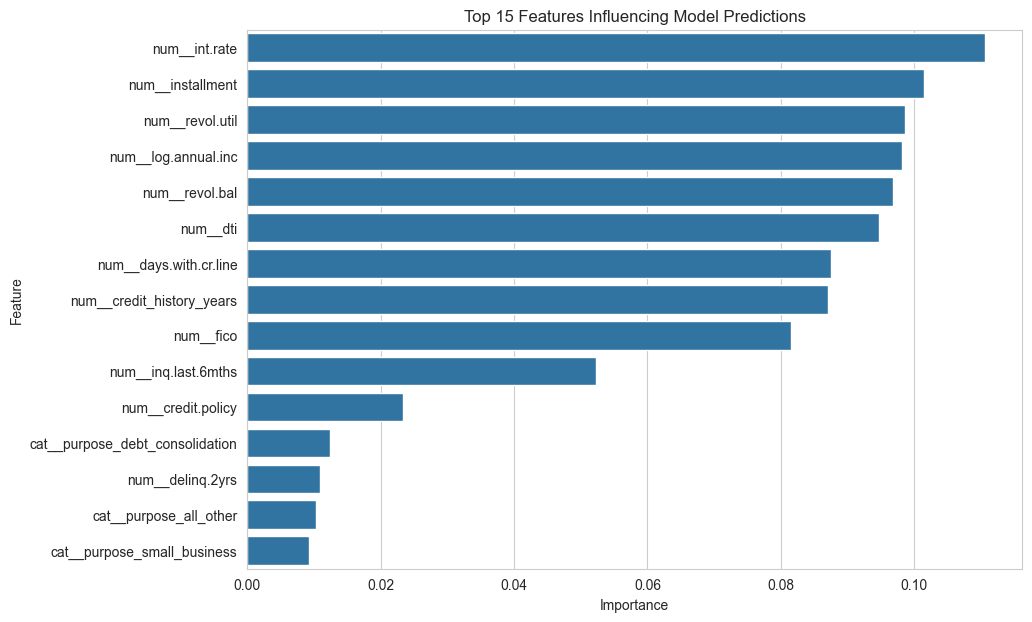

In [51]:
# ============================================
# 40. TOP 15 FEATURE IMPORTANCES
# ============================================

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Influencing Model Predictions")

plt.show()

In [52]:
# ============================================
# 41. SAVE MODEL
# ============================================

model_artifact = {
    "model": best_rf,
    "threshold": float(best_threshold)
}

joblib.dump(
    model_artifact,
    "loan_default_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [53]:
# ============================================
# 42. SINGLE BORROWER PREDICTION
# ============================================

sample_borrower = X_test.iloc[[0]]

probability = best_rf.predict_proba(
    sample_borrower
)[:, 1][0]

prediction = int(
    probability >= best_threshold
)

print("Risk probability:", round(probability, 4))
print("Prediction:", prediction)

Risk probability: 0.316
Prediction: 1


In [54]:
# ============================================
# 43. USER-FRIENDLY PREDICTION
# ============================================

if prediction == 1:

    print("Prediction: Higher risk of not fully repaying")

else:

    print("Prediction: Lower predicted risk of not fully repaying")

print(
    f"Predicted probability: {probability:.2%}"
)

Prediction: Higher risk of not fully repaying
Predicted probability: 31.60%


In [55]:
# ============================================
# 44. CROSS-VALIDATION
# ============================================

cv_scores = []

for train_idx, val_idx in cv.split(X_train, y_train):

    X_cv_train = X_train.iloc[train_idx]
    X_cv_val = X_train.iloc[val_idx]

    y_cv_train = y_train.iloc[train_idx]
    y_cv_val = y_train.iloc[val_idx]

    model = best_rf

    model.fit(
        X_cv_train,
        y_cv_train
    )

    val_probability = model.predict_proba(
        X_cv_val
    )[:, 1]

    score = average_precision_score(
        y_cv_val,
        val_probability
    )

    cv_scores.append(score)

print("Cross-validation PR-AUC scores:")
print(cv_scores)

print(
    "\nMean CV PR-AUC:",
    np.mean(cv_scores)
)

print(
    "Std CV PR-AUC:",
    np.std(cv_scores)
)

Cross-validation PR-AUC scores:
[0.2575426750183115, 0.2524162787762254, 0.3024999855093217, 0.30170712172026665, 0.2693828409325139]

Mean CV PR-AUC: 0.2767097803913278
Std CV PR-AUC: 0.02145338175896793


In [56]:
# ============================================
# 45. REFIT FINAL MODEL
# ============================================

best_rf.fit(
    X_train,
    y_train
)

print("Final model trained successfully.")

Final model trained successfully.


In [57]:
# ============================================
# 46. FINAL MODEL SUMMARY
# ============================================

final_probability = best_rf.predict_proba(
    X_test
)[:, 1]

final_prediction = (
    final_probability >= best_threshold
).astype(int)

print("FINAL MODEL PERFORMANCE")
print("=" * 60)

print(
    "Accuracy:",
    round(
        accuracy_score(
            y_test,
            final_prediction
        ),
        4
    )
)

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            final_prediction,
            zero_division=0
        ),
        4
    )
)

print(
    "Recall:",
    round(
        recall_score(
            y_test,
            final_prediction,
            zero_division=0
        ),
        4
    )
)

print(
    "F1:",
    round(
        f1_score(
            y_test,
            final_prediction,
            zero_division=0
        ),
        4
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            final_probability
        ),
        4
    )
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test,
            final_probability
        ),
        4
    )
)

FINAL MODEL PERFORMANCE
Accuracy: 0.5934
Precision: 0.2354
Recall: 0.684
F1: 0.3503
ROC-AUC: 0.6796
PR-AUC: 0.2825
